In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("../data/cleaned_sp500.csv")

df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,A,2000-01-03,47.07,47.18,40.27,43.04,43.04,4674353
1,A,2000-01-04,40.72,41.17,38.70,39.75,39.75,4765083
2,A,2000-01-05,39.60,39.75,36.05,37.28,37.28,5758642
3,A,2000-01-06,36.83,37.06,34.74,35.86,35.86,2534434
4,A,2000-01-07,35.30,39.41,35.27,38.85,38.85,2819626


# Stock selection

In [3]:
apple = df[df['Ticker'] == 'AAPL'].copy()

apple = apple.sort_values('Date')

apple.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
11705,AAPL,2000-01-03,0.79,0.84,0.76,0.84,0.84,535796800
11706,AAPL,2000-01-04,0.81,0.83,0.76,0.77,0.77,512377600
11707,AAPL,2000-01-05,0.78,0.83,0.77,0.78,0.78,778321600
11708,AAPL,2000-01-06,0.79,0.80,0.71,0.71,0.71,767972800
11709,AAPL,2000-01-07,0.72,0.76,0.72,0.75,0.75,460734400


## MAn​=(1/n)​∑(i=1,n)​Pi​

In [4]:
apple['MA10'] = apple['Close'].rolling(10).mean()

apple['MA50'] = apple['Close'].rolling(50).mean()

apple['MA200'] = apple['Close'].rolling(200).mean()

In [5]:
apple['Daily_Return'] = apple['Close'].pct_change()

In [6]:
apple['Volatility'] = apple['Daily_Return'].rolling(10).std()

# RSI (Relative Strength Index)

RSI=100−(100/(1-RS))​


In [7]:
delta = apple['Close'].diff()

gain = delta.where(delta > 0, 0)

loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

apple['RSI'] = 100 - (100 / (1 + rs))

# MACD

In [8]:
ema12 = apple['Close'].ewm(span=12, adjust=False).mean()

ema26 = apple['Close'].ewm(span=26, adjust=False).mean()

apple['MACD'] = ema12 - ema26

Upper Band=MA20​+2σ

In [9]:
apple['BB_Middle'] = apple['Close'].rolling(20).mean()

std = apple['Close'].rolling(20).std()

apple['BB_Upper'] = apple['BB_Middle'] + (2 * std)

apple['BB_Lower'] = apple['BB_Middle'] - (2 * std)

In [10]:
apple['Target'] = apple['Close'].shift(-1)

In [11]:
apple = apple.dropna()

In [12]:
features = [
    'Open',
    'High',
    'Low',
    'Volume',
    'MA10',
    'MA50',
    'MA200',
    'Daily_Return',
    'Volatility',
    'RSI',
    'MACD',
    'BB_Upper',
    'BB_Lower'
]

In [13]:
X = apple[features]

y = apple['Target']

# Time-Series Split

In [14]:
split_index = int(len(apple) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# Model Train

In [15]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [16]:
predictions = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 56.44975159122242
RMSE: 69.5932516725623
R2 Score: -1.8082368575530139


# Lets visualise

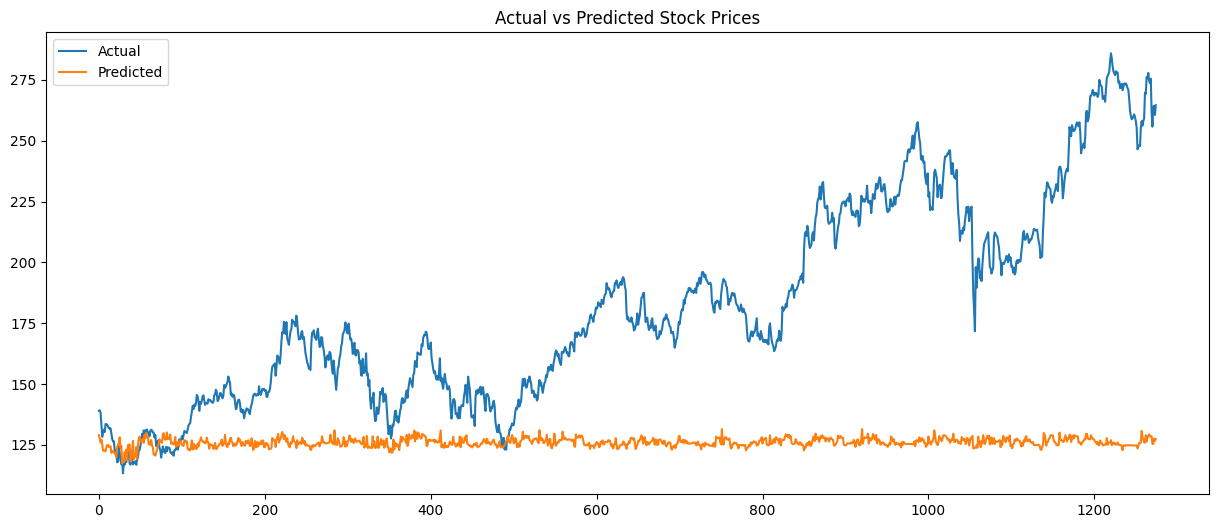

In [18]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values, label='Actual')

plt.plot(predictions, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Stock Prices")

plt.show()

In [19]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,Low,0.345662
6,MA200,0.311573
1,High,0.156415
5,MA50,0.093167
4,MA10,0.043272
0,Open,0.041520
12,BB_Lower,0.004955
11,BB_Upper,0.003096
8,Volatility,0.000113
7,Daily_Return,0.000065


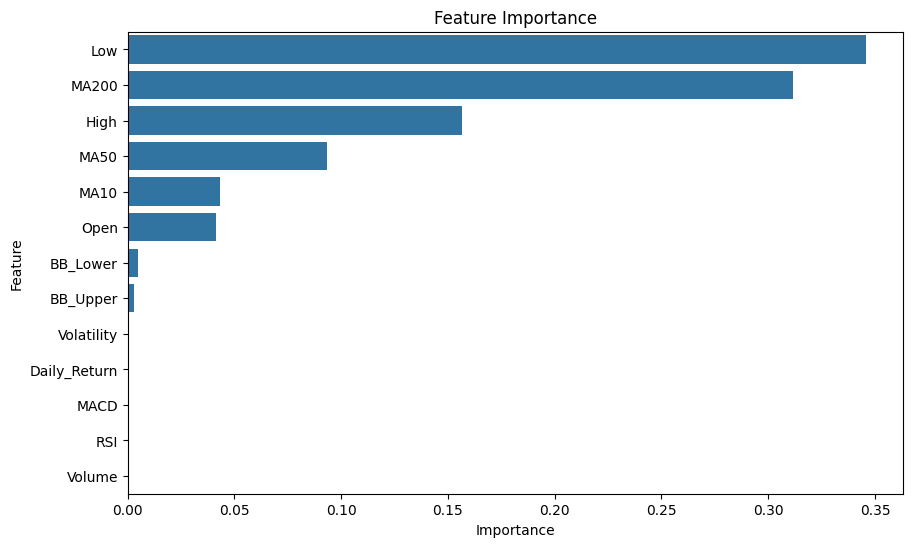

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [21]:
import joblib

joblib.dump(model, "../models/xgboost_stock_model.pkl")

['../models/xgboost_stock_model.pkl']